### 1. Importing project modules

In [2]:
import sys
import os
from matplotlib import pyplot as plt

sys.path.append(
    os.path.abspath("../models")
)

import time
import json
import pandas as pd

from data_loader import load_input_data
from allocations_algorithms import greedy_heuristic_allocate, solve_allocation_with_scip
from models_and_KPIS import calculate_kpis

### 2. Loading data-directory and other parameters

In [3]:
DATA_DIR =  r"D:\Projects\slab-allocation-system\intelligent-slab-allocation-system\data"


PROBLEM_SIZES = [
    ("s10_p20", 10, 20),
    ("s20_p35", 20, 35),
    ("s30_p50", 30, 50),
    ("s40_p80", 40, 80)
]

ORDER_FULFILMENT_WEIGHT = 0.4
YIELD_LOSS_MINIMIsATION_WEIGHT = 0.6

### 3. Running Experiments for all sizes

In [4]:
results = []

for problem_name, slab_count, plate_count in PROBLEM_SIZES:

    print("=" * 70)
    print(f"Running problem: {problem_name}")
    print("=" * 70)

    slab_file = os.path.join(
        DATA_DIR,
        f"slab_inventory_input_{problem_name}.xlsx"
    )

    order_file = os.path.join(
        DATA_DIR,
        f"orders_input_{problem_name}.xlsx"
    )

    # ---------------------------------------------------------
    # Load data
    # ---------------------------------------------------------

    slabs, orders = load_input_data(
                slab_file,
                order_file,
                file_format="excel"
            )

    print(
        f"Loaded {len(slabs)} slabs "
        f"and {sum(len(o.plates) for o in orders)} plates"
    )

    # =========================================================
    # GREEDY
    # =========================================================

    start_time = time.perf_counter()

    greedy_allocations, greedy_unallocated = (
        greedy_heuristic_allocate(
            slabs,
            orders
        )
    )

    greedy_runtime = (
        time.perf_counter() - start_time
    )

    greedy_kpis = calculate_kpis(
        slabs=slabs,
        orders=orders,
        allocations=greedy_allocations,
        unallocated_orders=greedy_unallocated
    )

    results.append({
        "problem": problem_name,
        "slabs": slab_count,
        "plates": plate_count,
        "algorithm": "Greedy",
        **greedy_kpis,

         # Additional experiment metrics
        "total_allocations": len(greedy_allocations),
        "runtime_seconds": greedy_runtime

    })

    # =========================================================
    # SCIP
    # =========================================================

    start_time = time.perf_counter()

    scip_allocations, scip_unallocated = (
        solve_allocation_with_scip(
            slabs=slabs,
            orders=orders,
            fulfilment_weight=ORDER_FULFILMENT_WEIGHT,
            yield_loss_weight=YIELD_LOSS_MINIMIsATION_WEIGHT
        )
    )

    scip_runtime = (
        time.perf_counter() - start_time
    )

    scip_kpis = calculate_kpis(
        slabs=slabs,
        orders=orders,
        allocations=scip_allocations,
        unallocated_orders=scip_unallocated
    )

    results.append({
        "problem": problem_name,
        "slabs": slab_count,
        "plates": plate_count,
        "algorithm": "SCIP",
        **scip_kpis,

        "total_allocations": len(scip_allocations),
        "runtime_seconds": scip_runtime
    })

    print(
        f"Greedy runtime: {greedy_runtime:.4f}s"
    )

    print(
        f"SCIP runtime:   {scip_runtime:.4f}s"
    )

Running problem: s10_p20
Loaded 10 slabs and 20 plates
SCIP model created
Plates with no feasible slab: ['P009', 'P020']
Allocation variables: 34
Order variables: 10
Total slab length expression created.
Material consumption expression created.
Yield loss expression created.
Order fulfilment expression created.
Weighted objective defined.
Number of allocation variables (x): 34
Number of order fulfilment variables (z): 10
Number of slab usage variables (y): 10
Number of constraints: 64
SCIP status: optimal
Optimization time: 0.016508817672729492
Objective value: 0.16526384187620896
SCIP allocations: 10
Greedy runtime: 0.0002s
SCIP runtime:   0.0217s
Running problem: s20_p35
Loaded 20 slabs and 35 plates
SCIP model created
Plates with no feasible slab: ['P009', 'P020', 'P029']
Allocation variables: 117
Order variables: 18
Total slab length expression created.
Material consumption expression created.
Yield loss expression created.
Order fulfilment expression created.
Weighted objective de

### 4. Result Analysis

In [5]:
results_df = pd.DataFrame(results)

results_df

,problem,slabs,plates,algorithm,material_consumption,yield_loss,slab_utilisation,order_fulfilment,total_allocations,runtime_seconds
0,s10_p20,10,20,Greedy,68.432816,23.567184,74.383495,0.500000,10,0.000155
1,s10_p20,10,20,SCIP,68.052768,6.947232,90.737025,0.500000,10,0.021674
2,s20_p35,20,35,Greedy,140.672600,43.327400,76.452500,0.611111,22,0.000384
3,s20_p35,20,35,SCIP,156.616145,19.383855,88.986446,0.722222,25,0.198625
4,s30_p50,30,50,Greedy,178.212464,61.787536,74.255193,0.600000,30,0.001070
5,s30_p50,30,50,SCIP,194.815220,6.184780,96.922995,0.733333,35,0.685033
6,s40_p80,40,80,Greedy,289.149238,64.850762,81.680576,0.550000,44,0.002001
7,s40_p80,40,80,SCIP,313.411811,26.588189,92.179944,0.625000,50,4.603439


In [6]:
comparison_df = results_df.pivot(
    index="problem",
    columns="algorithm",
    values=[
        "yield_loss",
        "slab_utilisation",
        "order_fulfilment",
        "runtime_seconds",
        "total_allocations"
    ]
)

comparison_df.round(3)

yield_loss         slab_utilisation         order_fulfilment         \
algorithm     Greedy    SCIP           Greedy    SCIP           Greedy   SCIP   
problem                                                                         
s10_p20       23.567   6.947           74.383  90.737            0.500  0.500   
s20_p35       43.327  19.384           76.453  88.986            0.611  0.722   
s30_p50       61.788   6.185           74.255  96.923            0.600  0.733   
s40_p80       64.851  26.588           81.681  92.180            0.550  0.625   

          runtime_seconds        total_allocations        
algorithm          Greedy   SCIP            Greedy  SCIP  
problem                                                   
s10_p20             0.000  0.022              10.0  10.0  
s20_p35             0.000  0.199              22.0  25.0  
s30_p50             0.001  0.685              30.0  35.0  
s40_p80             0.002  4.603              44.0  50.0

### 5. Plots for some KPIS

#### yield loss

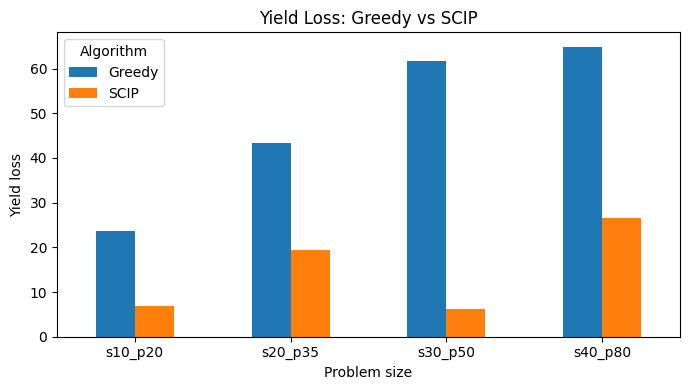

In [7]:


yield_plot = results_df.pivot(
    index="problem",
    columns="algorithm",
    values="yield_loss"
)

yield_plot.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Yield loss")
plt.xlabel("Problem size")
plt.title("Yield Loss: Greedy vs SCIP")
plt.xticks(rotation=0)
plt.legend(title="Algorithm")
plt.tight_layout()
plt.show()

#### Slab Utilisation vs Order Fulfilment

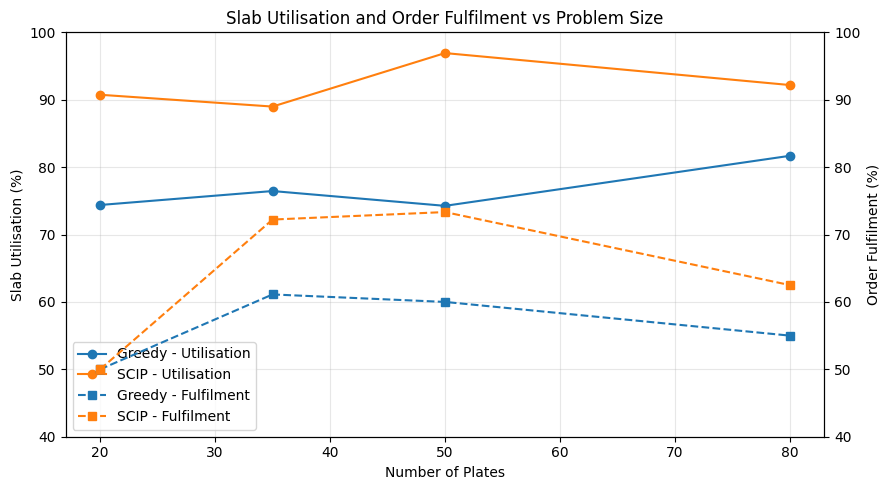

In [8]:

fig, ax1 = plt.subplots(figsize=(9, 5))

ax2 = ax1.twinx()

for algorithm in results_df["algorithm"].unique():

    data = (
        results_df[
            results_df["algorithm"] == algorithm
        ]
        .sort_values("plates")
    )

    # Slab utilisation
    ax1.plot(
        data["plates"],
        data["slab_utilisation"],
        marker="o",
        linestyle="-",
        label=f"{algorithm} - Utilisation"
    )

    # Order fulfilment
    ax2.plot(
        data["plates"],
        data["order_fulfilment"] * 100,
        marker="s",
        linestyle="--",
        label=f"{algorithm} - Fulfilment"
    )


# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------

ax1.set_xlabel("Number of Plates")
ax1.set_ylabel("Slab Utilisation (%)")
ax2.set_ylabel("Order Fulfilment (%)")

ax1.set_ylim(40, 100)
ax2.set_ylim(40, 100)

ax1.set_title(
    "Slab Utilisation and Order Fulfilment vs Problem Size"
)

# ---------------------------------------------------------
# Combined legend
# ---------------------------------------------------------

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Performance Improvement (by yield loss reduction

In [10]:
summary = results_df.pivot(
    index="problem",
    columns="algorithm",
    values="yield_loss"
)

summary["SCIP_improvement_%"] = (
    (summary["Greedy"] - summary["SCIP"])
    / summary["Greedy"]
    * 100
)

summary.round(2)

algorithm,Greedy,SCIP,SCIP_improvement_%
problem,,,
s10_p20,23.57,6.95,70.52
s20_p35,43.33,19.38,55.26
s30_p50,61.79,6.18,89.99
s40_p80,64.85,26.59,59.00
